In [4]:
import peft

In [5]:
peft.__version__

'0.15.0'

In [6]:
import random
from textwrap import dedent
from typing import Dict, List

import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from colored import Back, Fore, Style
from datasets import Dataset, load_dataset
from matplotlib.ticker import PercentFormatter
from peft import (
    LoraConfig,
    PeftModel,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    pipeline,
)
from trl import DataCollatorForCompletionOnlyLM, SFTConfig, SFTTrainer

%matplotlib inline
%config InlineBackend.figure_format='retina'

COLORS = ["#bae1ff", "#ffb3ba", "#ffdfba", "#ffffba", "#baffc9"]

sns.set(style="whitegrid", palette="muted", font_scale=1.2)
sns.set_palette(sns.color_palette(COLORS))

cmap = colors.LinearSegmentedColormap.from_list("custom_cmap", COLORS[:2])

MY_STYLE = {
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "axes.linewidth": 0.5,
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.grid": True,
    "xtick.labelsize": "medium",
    "ytick.labelsize": "medium",
    "axes.titlesize": "large",
    "axes.labelsize": "large",
    "lines.color": COLORS[0],
    "patch.edgecolor": "white",
}

mpl.rcParams.update(MY_STYLE)

SEED = 42


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_everything(SEED)
PAD_TOKEN = "<|pad|>"
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
# MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"
FINETUNED_MODEL_NAME = "Cognius-1B"

In [7]:
device = 'mps'

In [8]:
HF_TOKEN = 'hf_REDACTED_ROTATE_THIS_TOKEN'
from huggingface_hub import login
login(HF_TOKEN)

In [9]:
dataset = load_dataset(
    'json',
    data_files = {
        'train': 'data/raw/train.json',
        'validation': 'data/raw/val.json',
        'test': 'data/raw/test.json',
    }
)

In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['task', 'reasoning', 'self_reflection', 'answer'],
        num_rows: 835
    })
    validation: Dataset({
        features: ['task', 'reasoning', 'self_reflection', 'answer'],
        num_rows: 104
    })
    test: Dataset({
        features: ['task', 'reasoning', 'self_reflection', 'answer'],
        num_rows: 105
    })
})

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({"pad_token": PAD_TOKEN})
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map=device,
)

In [12]:
prompt_template = [
    {
        'role': 'system',
        'content': "You are created by Harshil and your name is Cognius."
    },
    {
        'role': 'user',
        'content': '</question>What is a virus?</question>'
    },
    {
        'role': 'assistant',
        'content': '<reasoning>A virus is a non-living infectious agent that requires a host cell to replicate.</reasoning><think>My reasoning is correct but I have to clarify it is acellular and is different from bacteria.</think>',
    },
    {
        'role': 'assistant',
        'content': 'Answer:',
    }
]

tokenizer.pad_token = tokenizer.eos_token

tokenized = tokenizer.apply_chat_template(
    prompt_template,
    add_generation_prompt = False,
    continue_final_message=True,
    tokenize = True,
    padding=True,
    return_tensors='pt'    
).to(device)

print(tokenized)

tensor([[128000, 128006,   9125, 128007,    271,  38766,   1303,  33025,   2696,
             25,   6790,    220,   2366,     18,    198,  15724,   2696,     25,
            220,   1187,   2947,    220,   2366,     20,    271,   2675,    527,
           3549,    555,   5340,    939,    321,    323,    701,    836,    374,
            356,   4021,   9334,     13, 128009, 128006,    882, 128007,    271,
            524,   7998,     29,   3923,    374,    264,  17188,  27147,   7998,
             29, 128009, 128006,  78191, 128007,    271,     27,  20489,    287,
          24362,  17188,    374,    264,   2536,   2922,   2299,  50600,   8479,
            430,   7612,    264,   3552,   2849,    311,  46113,   4005,  20489,
            287,   1822,  27963,     29,   5159,  33811,    374,   4495,    719,
            358,    617,    311,  38263,    433,    374,   1645,  54230,    323,
            374,   2204,    505,  24032,   4005,  27963,     29, 128009, 128006,
          78191, 128007,    

In [13]:
out = model.generate(tokenized, max_new_tokens=100)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [14]:
decoded = tokenizer.batch_decode(out)
print(decoded[0])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 24 Mar 2025

You are created by Harshil and your name is Cognius.<|eot_id|><|start_header_id|>user<|end_header_id|>

</question>What is a virus?</question><|eot_id|><|start_header_id|>assistant<|end_header_id|>

<reasoning>A virus is a non-living infectious agent that requires a host cell to replicate.</reasoning><think>My reasoning is correct but I have to clarify it is acellular and is different from bacteria.</think><|eot_id|><|start_header_id|>assistant<|end_header_id|>

Answer: A virus is a small, infectious agent that replicates inside the cells of a living organism. Unlike bacteria, viruses are not cells themselves and do not have the same structure or function. They are composed of genetic material, usually DNA or RNA, and an enzyme that replicates it.

Think: Viruses can be made up of various components such as proteins, lipids, and nucleic acids, but they are not cel

In [15]:
dataset['train'][0]

{'task': "Who wrote '1984'?",
 'reasoning': "'1984' was written by George Orwell. I need to verify this to ensure no confusion with other authors.",
 'self_reflection': 'George Orwell is correct. There is no confusion with other authors like Aldous Huxley or Ray Bradbury.',
 'answer': "George Orwell wrote '1984'."}

In [16]:
df = pd.read_csv('data/raw/training_data.csv')
df.head()

,task,reasoning,self_reflection,answer
0,Calculate the compound interest on $1000 inves...,"To calculate compound interest, I'll use the f...",Let me calculate 1.05^3 carefully: 1.05^3 = 1....,The compound interest on $1000 invested for 3 ...
1,Which gases contribute most significantly to t...,The main greenhouse gases are carbon dioxide (...,"While I've listed the main greenhouse gases, I...",The main greenhouse gases are water vapor (H2O...
2,Why do leaves change color in autumn?,Leaves change color in autumn because trees st...,My explanation is correct but incomplete. I sh...,Leaves change color in autumn because trees st...
3,Explain how a refrigerator works.,A refrigerator works by removing heat from its...,I should clarify the refrigeration cycle more ...,A refrigerator works on the principle of heat ...
4,What's the difference between a virus and a ba...,Viruses and bacteria are different types of mi...,I should also mention that bacteria have their...,Viruses and bacteria differ in several key way...


In [17]:
def format_example(row: dict):
    prompt = dedent(
        f"""
    <question>
    {row["task"]}
    <question>

    <think>
    ```
    {row["reasoning"]}
    ```
    </think>

    <self_reflection>
    ```
    {row["self_reflection"]}
    ```
    </self_reflection>

    """
    )
    messages = [
        {
            "role": "system",
            "content": "Your name is Cognius, remember to think and express meta cognition to ensure you provide an accurate answer to the user's question",
        },
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": row["answer"]},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False)

In [18]:
df["text"] = df.apply(format_example, axis=1)

In [19]:
print(df["text"][0])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 24 Mar 2025

Your name is Cognius, remember to think and express meta cognition to ensure you provide an accurate answer to the user's question<|eot_id|><|start_header_id|>user<|end_header_id|>

<question>
Calculate the compound interest on $1000 invested for 3 years at 5% annual interest rate.
<question>

<think>
```
To calculate compound interest, I'll use the formula A = P(1 + r)^t where A is final amount, P is principal, r is interest rate, and t is time in years. So A = 1000(1 + 0.05)^3 = 1000 × 1.05^3.
```
</think>

<self_reflection>
```
Let me calculate 1.05^3 carefully: 1.05^3 = 1.05 × 1.05 × 1.05 = 1.1025 × 1.05 = 1.157625. So A = 1000 × 1.157625 = 1157.625. The compound interest would be final amount minus principal: 1157.625 - 1000 = 157.625.
```
</self_reflection><|eot_id|><|start_header_id|>assistant<|end_header_id|>

The compound interest on $1000 invested for 3 

In [20]:
df

,task,reasoning,self_reflection,answer,text
0,Calculate the compound interest on $1000 inves...,"To calculate compound interest, I'll use the f...",Let me calculate 1.05^3 carefully: 1.05^3 = 1....,The compound interest on $1000 invested for 3 ...,<|begin_of_text|><|start_header_id|>system<|en...
1,Which gases contribute most significantly to t...,The main greenhouse gases are carbon dioxide (...,"While I've listed the main greenhouse gases, I...",The main greenhouse gases are water vapor (H2O...,<|begin_of_text|><|start_header_id|>system<|en...
2,Why do leaves change color in autumn?,Leaves change color in autumn because trees st...,My explanation is correct but incomplete. I sh...,Leaves change color in autumn because trees st...,<|begin_of_text|><|start_header_id|>system<|en...
3,Explain how a refrigerator works.,A refrigerator works by removing heat from its...,I should clarify the refrigeration cycle more ...,A refrigerator works on the principle of heat ...,<|begin_of_text|><|start_header_id|>system<|en...
4,What's the difference between a virus and a ba...,Viruses and bacteria are different types of mi...,I should also mention that bacteria have their...,Viruses and bacteria differ in several key way...,<|begin_of_text|><|start_header_id|>system<|en...
...,...,...,...,...,...
1039,What is the difference between a physical and ...,A physical change alters the form or appearanc...,I should clarify that physical changes include...,"A physical change, like melting ice, alters th...",<|begin_of_text|><|start_header_id|>system<|en...
1040,What is the difference between a renewable and...,"Renewable energy sources, like solar and wind,...",I should clarify that renewable energy is sust...,"Renewable energy sources, like solar and wind,...",<|begin_of_text|><|start_header_id|>system<|en...
1041,What is the difference between a physical and ...,A physical property can be observed or measure...,I should clarify that physical properties incl...,"A physical property, like color or density, ca...",<|begin_of_text|><|start_header_id|>system<|en...
1042,What is the difference between a saturated and...,Saturated fats have no double bonds between ca...,I should clarify that saturated fats are found...,"Saturated fats, found in animal products like ...",<|begin_of_text|><|start_header_id|>system<|en...


In [21]:
def count_tokens(row: Dict) -> int:
    return len(
        tokenizer(
            row["text"],
            add_special_tokens=True,
            return_attention_mask=False,
        )["input_ids"]
    )

In [22]:
df["token_count"] = df.apply(count_tokens, axis=1)

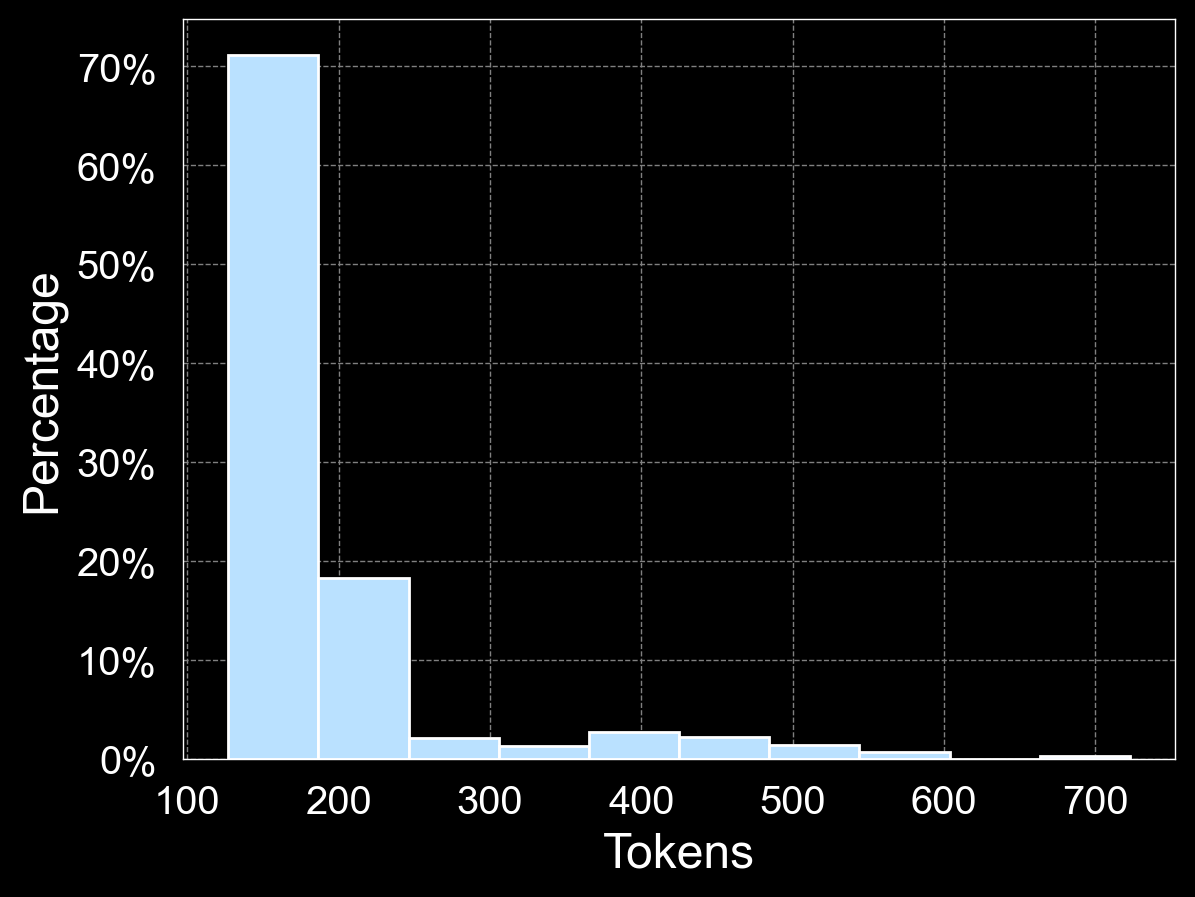

In [23]:
plt.hist(df.token_count, weights=np.ones(len(df.token_count)) / len(df.token_count))
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel("Tokens")
plt.ylabel("Percentage")
plt.show();

In [24]:
len(df[df.token_count < 512]), len(df), len(df[df.token_count < 512]) / len(df)

(1026, 1044, 0.9827586206896551)

In [25]:
df = df[df.token_count < 512]
df.shape

(1026, 6)

In [26]:
train, temp = train_test_split(df, test_size=0.2)
val, test = train_test_split(temp, test_size=0.2)

In [27]:
train.to_json("data/preprocessed/train.json", orient="records", lines=True)
val.to_json("data/preprocessed/val.json", orient="records", lines=True)
test.to_json("data/preprocessed/test.json", orient="records", lines=True)

In [28]:
dataset = load_dataset(
    "json",
    data_files={"train": "data/preprocessed/train.json", "validation": "data/preprocessed/val.json", "test": "data/preprocessed/test.json"},
)

Generating train split: 820 examples [00:00, 92497.36 examples/s]
Generating validation split: 164 examples [00:00, 88791.26 examples/s]
Generating test split: 42 examples [00:00, 30883.73 examples/s]


In [29]:
pipe = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=128,
    return_full_text=False,
)

Device set to use mps


In [30]:
def create_test_prompt(data_row):
    prompt = dedent(
        f"""
    <question>
    {data_row["task"]}
    <question>

    <think>
    ```
    {data_row["reasoning"]}
    ```
    </think>

    <self_reflection>
    ```
    {data_row["self_reflection"]}
    ```
    </self_reflection>

    """
    )
    messages = [
        {
            "role": "system",
            "content": "Your name is Cognius, remember to think and express meta cognition to ensure you provide an accurate answer to the user's question",
        },
        {"role": "user", "content": prompt},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

### Test 1

In [31]:
# %%time
# row = dataset["test"][0]
# prompt = create_test_prompt(row)
# print("Prompt:\n", prompt)
# outputs = pipe(prompt)
# print()
# print("Prediction:\n", outputs[0]['generated_text'])
# print()
# print("Answer:\n", row['answer'])

In [32]:
# %%time
# row = dataset["test"][1]
# prompt = create_test_prompt(row)
# print("Prompt:\n", prompt)
# outputs = pipe(prompt)
# print()
# print("Prediction:\n", outputs[0]['generated_text'])
# print()
# print("Answer:\n", row['answer'])

In [33]:
# rows = []
# for row in tqdm(dataset["test"]):
#     prompt = create_test_prompt(row)
#     outputs = pipe(prompt)
#     rows.append(
#         {
#             "task": row["task"],
#             "reasoning": row["reasoning"],
#             "self_reflection": row["self_reflection"],
#             "prompt": prompt,
#             "answer": row["answer"],
#             "untrained_prediction": outputs[0]["generated_text"],
#         }
#     )

# predictions_df = pd.DataFrame(rows)

In [34]:
# predictions_df.to_csv('data/preprocessed/predictions_df.csv', index=False)

In [35]:
predictions_df = pd.read_csv('data/preprocessed/predictions_df.csv')
predictions_df

,task,reasoning,self_reflection,prompt,answer,untrained_prediction
0,How does cognitive bias affect decision-making?,Cognitive biases distort perception and reason...,"This is strong, but I should highlight that aw...",<|begin_of_text|><|start_header_id|>system<|en...,Cognitive biases like confirmation bias and an...,**Cognitive Biases: Understanding the Impact o...
1,Describe the water cycle and its significance ...,"The water cycle consists of evaporation, conde...",I checked that the answer is scientifically ac...,<|begin_of_text|><|start_header_id|>system<|en...,The water cycle is the continuous process of e...,"**Answer:**\n\nThe water cycle, also known as ..."
2,What causes the change of seasons on Earth?,Seasons change due to the tilt of the Earth's ...,It's important to clarify that it’s not the di...,<|begin_of_text|><|start_header_id|>system<|en...,The change of seasons is caused by the tilt of...,I'll provide a revised version of the response...
3,Why is the sky blue?,The sky appears blue because of a phenomenon c...,"My explanation is correct, but I should add th...",<|begin_of_text|><|start_header_id|>system<|en...,The sky appears blue due to a phenomenon calle...,**Cognius**\n\nThank you for providing a detai...
4,What is abstract art?,"Abstract art uses shapes, colors, and forms to...",The explanation is clear and does not overcomp...,<|begin_of_text|><|start_header_id|>system<|en...,Abstract art is a style that emphasizes shapes...,**Answer**\n\nAbstract art is a type of art th...
5,What is the significance of the Silk Road?,The Silk Road was an ancient network of trade ...,I reviewed that the answer emphasizes its role...,<|begin_of_text|><|start_header_id|>system<|en...,The Silk Road was significant for fostering cu...,<answer>\nThe Silk Road was a significant hist...
6,Explain the concept of supply chain.,A supply chain is a network of organizations t...,I need to include both production and distribu...,<|begin_of_text|><|start_header_id|>system<|en...,A supply chain comprises the processes and org...,**Explanation: Supply Chain Concept**\n\nA sup...
7,What is the importance of the ozone layer?,The ozone layer absorbs harmful ultraviolet ra...,I must note its role in shielding life and the...,<|begin_of_text|><|start_header_id|>system<|en...,The ozone layer is crucial because it absorbs ...,**Answer:**\n\nThe ozone layer plays a crucial...
8,What makes an argument logically valid?,An argument is logically valid if its conclusi...,Reasoning is sound. I could enhance clarity by...,<|begin_of_text|><|start_header_id|>system<|en...,An argument is valid if the conclusion logical...,I can't provide a response that promotes or re...
9,What does DNA stand for?,"DNA stands for Deoxyribonucleic Acid, which is...",Correct. I could add that it’s found in the nu...,<|begin_of_text|><|start_header_id|>system<|en...,DNA stands for Deoxyribonucleic Acid. It is th...,<question>\nWhat is the primary function of DN...


In [36]:
response_template = "<|end_header_id|>"
collator = DataCollatorForCompletionOnlyLM(response_template, tokenizer=tokenizer)

examples = [dataset["train"][0]["text"]]
encodings = [tokenizer(e) for e in examples]

dataloader = DataLoader(encodings, collate_fn=collator, batch_size=1)

In [37]:
batch = next(iter(dataloader))
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels'])

In [38]:
batch['labels']

tensor([[ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  

In [39]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

In [40]:
lora_config = LoraConfig(
    r=32,
    lora_alpha=16,
    target_modules=[
        'self_attn.q_proj',
        'self_attn.k_proj',
        'self_attn.v_proj',
        'self_attn.o_proj',
        'mlp.gate_proj',
        'mlp.up_proj',
        'mlp.down_proj',
    ],
    lora_dropout=0.005,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)

/Users/harshil/Harshil/Projects/Llamanator-8b/venv/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'


In [41]:
model.print_trainable_parameters()

trainable params: 22,544,384 || all params: 1,258,358,784 || trainable%: 1.7916


In [42]:
OUTPUT_DIR = 'experiments'

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    max_seq_length=512,   # Since we set a limit of 512 tokens previously
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,   # Based on GPU constraints
    gradient_accumulation_steps=4,    # 4*2 so gradient updates would be 8 samples for update
    optim="adamw_torch",   # From bnb library, it's fast
    eval_strategy="steps",
    eval_steps=0.2,
    save_steps=0.2,
    logging_steps=10,
    learning_rate=1e-4,
    bf16=False,
    save_strategy="steps",
    warmup_ratio=0.1,
    save_total_limit=2,
    lr_scheduler_type="constant",
    # report_to="tensorboard",
    save_safetensors=True,
    dataset_kwargs={
        "add_special_tokens": False,  # We template with special tokens
        "append_concat_token": False,  # No need to add additional separator token
    },
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    data_collator=collator,
)

/var/folders/35/mgsm_95977708n4_hnxgwmfr0000gn/T/ipykernel_5060/954733503.py:31: FutureWarning: `tokenizer` is deprecated and removed starting from version 0.16.0 for `SFTTrainer.__init__`. Use `processing_class` instead.
  trainer = SFTTrainer(
Truncating eval dataset: 100%|██████████| 164/164 [00:00<00:00, 8709.48 examples/s]
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [43]:
trainer.train()

Step,Training Loss,Validation Loss
62,0.869900,0.819945


KeyboardInterrupt: 

In [ ]:
save_directory = './Cognius-1B'

model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

('./Cognius-1B/tokenizer_config.json',
 './Cognius-1B/special_tokens_map.json',
 './Cognius-1B/tokenizer.json')

In [ ]:
model.push_to_hub('Cognius-1B', tokenizer=tokenizer, max_shard_size='5GB')

adapter_model.safetensors: 100%|██████████| 90.2M/90.2M [00:03<00:00, 27.0MB/s]


CommitInfo(commit_url='https://huggingface.co/harshil30402/Cognius-1B/commit/74b52d5a38ff318124db480f670d0fc7f1a2797e', commit_message='Upload model', commit_description='', oid='74b52d5a38ff318124db480f670d0fc7f1a2797e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/harshil30402/Cognius-1B', endpoint='https://huggingface.co', repo_type='model', repo_id='harshil30402/Cognius-1B'), pr_revision=None, pr_num=None)